In [51]:
pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

Note: you may need to restart the kernel to use updated packages.


In [52]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [53]:
!pip install langgraph

In [54]:
!pip install langchain

In [55]:
pip install google-genai langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [56]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [57]:
!pip install dotenv

In [58]:


from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import os
from langchain_community.embeddings import HuggingFaceEmbeddings

In [59]:
load_dotenv()

True

In [60]:
llm= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [61]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()


In [62]:
len(docs)

11

In [63]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [64]:

len(chunks)


16

In [65]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [66]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [67]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


In [68]:

vector_store

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [75]:
@tool
def rag_tool(query: str) -> dict:

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [76]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [77]:


class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [78]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [73]:

tool_node = ToolNode(tools)

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

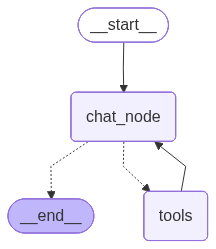

In [80]:
chatbot

In [79]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "give all problem statemenet"
                )
            )
        ]
    }
)

In [81]:
print(result['messages'][-1].content)

[{'type': 'text', 'text': "Here are the key aspects of a problem statement as described in the document:\n\n*   **Explain the problem:** Clearly articulate the problem.\n*   **Identify target users/stakeholders:** Define who would benefit from the solution and describe their needs and pain points.\n*   **Problem description and business scenario:** Provide relevant background information, data, or context to explain the problem's significance and impact. Discuss industry and business trends, needs, and scenarios.\n*   **Problem scope:** Define the boundaries and scope of the problem, including any limitations or specific requirements.", 'extras': {'signature': 'CoQJAb4+9vvRjtRPLQfITrBY4v+hq6audXSrsRFRqGNq9l6l0JdXadIALTY0BMAoAKnAIMJU3nuk9S6Ye8jEHpCpTY4ZoDuNvuEgkqGdmKAyfy3FDpHtBs3wRlTMX/lQP/7rSK1ja+h5LdBZxqdfeZTPM3dalGHUXxpYPPtpCqh7msm+NzDQcgaN7BJUobutjL8wZ0lNaj1Kxla5De7MB+LlWhValvVmpJFBeBzG81RfCo6sqePeWZc6gsVZgKPQw5hI9vpBvaFcAgqno9tFWKDj2MVAzk4QKNYruYAzWOXmJKoD11hoyUrJojc3f5GYPCEmbAyNMD